In [16]:
# Cell 1 — Imports and paths
from pathlib import Path
import pandas as pd

BASE_DIR = Path("/data/shared/fsibilla/clean_code/Q1/feature_importance")
OUTPUT_PATH = BASE_DIR / "full_results.csv"

BASE_DIR, OUTPUT_PATH

(PosixPath('/data/shared/fsibilla/clean_code/Q1/feature_importance'),
 PosixPath('/data/shared/fsibilla/clean_code/Q1/feature_importance/full_results.csv'))

In [17]:
# Cell 2 — Find all experiment files
# Expected structure:
# /data/shared/fsibilla/clean_code/Q1/feature_importance/{experiment_name}/feature_importance_improvements.csv

csv_files = sorted(BASE_DIR.glob("*/feature_importance_improvements.csv"))

print(f"Found {len(csv_files)} experiment files.")
for f in csv_files[:10]:
    print(f)

Found 8 experiment files.
/data/shared/fsibilla/clean_code/Q1/feature_importance/eth_micron/feature_importance_improvements.csv
/data/shared/fsibilla/clean_code/Q1/feature_importance/lka_micron/feature_importance_improvements.csv
/data/shared/fsibilla/clean_code/Q1/feature_importance/lka_vam/feature_importance_improvements.csv
/data/shared/fsibilla/clean_code/Q1/feature_importance/moz_vam/feature_importance_improvements.csv
/data/shared/fsibilla/clean_code/Q1/feature_importance/nga_micron/feature_importance_improvements.csv
/data/shared/fsibilla/clean_code/Q1/feature_importance/nga_mics/feature_importance_improvements.csv
/data/shared/fsibilla/clean_code/Q1/feature_importance/yem_mvam/feature_importance_improvements.csv
/data/shared/fsibilla/clean_code/Q1/feature_importance/zwe_mics/feature_importance_improvements.csv


In [18]:
# Cell 3 — Load and merge all experiments into one dataframe
dfs = []

for csv_path in csv_files:
    experiment_name = csv_path.parent.name  # folder name = experiment name
    df = pd.read_csv(csv_path)
    
    # Add experiment identifier
    df["experiment"] = experiment_name
    
    # Optional: keep track of source file
    df["source_file"] = str(csv_path)
    
    dfs.append(df)

if not dfs:
    raise FileNotFoundError(f"No feature_importance_improvements.csv files found under {BASE_DIR}")

full_results = pd.concat(dfs, ignore_index=True)

print(f"Combined shape: {full_results.shape}")
full_results.head()

Combined shape: (25860, 10)


,context,seed,adm1,variable,imp_emd_over,imp_emd_nat,imp_ae_over,imp_ae_nat,experiment,source_file
0,full_context,1,Addis Ababa,va_ai,0.309850,-0.130903,0.852307,-0.138716,eth_micron,/data/shared/fsibilla/clean_code/Q1/feature_im...
1,full_context,1,Addis Ababa,fol_ai,0.079548,0.039488,0.266381,0.184102,eth_micron,/data/shared/fsibilla/clean_code/Q1/feature_im...
2,full_context,1,Addis Ababa,vb12_ai,0.048943,-0.674689,0.205152,-3.185863,eth_micron,/data/shared/fsibilla/clean_code/Q1/feature_im...
3,full_context,1,Addis Ababa,fe_ai,0.178170,0.128043,0.259087,0.619319,eth_micron,/data/shared/fsibilla/clean_code/Q1/feature_im...
4,full_context,1,Addis Ababa,zn_ai,0.142538,0.142539,0.204551,0.834056,eth_micron,/data/shared/fsibilla/clean_code/Q1/feature_im...


In [19]:
# Cell 4 — Reorder columns so experiment is first
preferred_order = ["experiment", "context", "seed", "adm1", "variable",
                   "imp_emd_over", "imp_emd_nat", "imp_ae_over", "imp_ae_nat", "source_file"]

existing_preferred = [c for c in preferred_order if c in full_results.columns]
remaining_cols = [c for c in full_results.columns if c not in existing_preferred]

full_results = full_results[existing_preferred + remaining_cols]

full_results.head()

,experiment,context,seed,adm1,variable,imp_emd_over,imp_emd_nat,imp_ae_over,imp_ae_nat,source_file
0,eth_micron,full_context,1,Addis Ababa,va_ai,0.309850,-0.130903,0.852307,-0.138716,/data/shared/fsibilla/clean_code/Q1/feature_im...
1,eth_micron,full_context,1,Addis Ababa,fol_ai,0.079548,0.039488,0.266381,0.184102,/data/shared/fsibilla/clean_code/Q1/feature_im...
2,eth_micron,full_context,1,Addis Ababa,vb12_ai,0.048943,-0.674689,0.205152,-3.185863,/data/shared/fsibilla/clean_code/Q1/feature_im...
3,eth_micron,full_context,1,Addis Ababa,fe_ai,0.178170,0.128043,0.259087,0.619319,/data/shared/fsibilla/clean_code/Q1/feature_im...
4,eth_micron,full_context,1,Addis Ababa,zn_ai,0.142538,0.142539,0.204551,0.834056,/data/shared/fsibilla/clean_code/Q1/feature_im...


In [20]:
# Cell 6 — Save full merged dataset
full_results.to_csv(OUTPUT_PATH, index=False)
print(f"Saved merged file to: {OUTPUT_PATH}")

Saved merged file to: /data/shared/fsibilla/clean_code/Q1/feature_importance/full_results.csv


## shapley values

In [21]:
# Cell 1 — Imports
from pathlib import Path
from math import factorial
from itertools import combinations
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [22]:
# Cell 2 — Paths and load disaggregated improvements
BASE_DIR = Path("/data/shared/fsibilla/clean_code/Q1/feature_importance")
FULL_RESULTS_PATH = BASE_DIR / "full_results.csv"

df = pd.read_csv(FULL_RESULTS_PATH)
print(df.shape)
df.head()

(25860, 10)


,experiment,context,seed,adm1,variable,imp_emd_over,imp_emd_nat,imp_ae_over,imp_ae_nat,source_file
0,eth_micron,full_context,1,Addis Ababa,va_ai,0.309850,-0.130903,0.852307,-0.138716,/data/shared/fsibilla/clean_code/Q1/feature_im...
1,eth_micron,full_context,1,Addis Ababa,fol_ai,0.079548,0.039488,0.266381,0.184102,/data/shared/fsibilla/clean_code/Q1/feature_im...
2,eth_micron,full_context,1,Addis Ababa,vb12_ai,0.048943,-0.674689,0.205152,-3.185863,/data/shared/fsibilla/clean_code/Q1/feature_im...
3,eth_micron,full_context,1,Addis Ababa,fe_ai,0.178170,0.128043,0.259087,0.619319,/data/shared/fsibilla/clean_code/Q1/feature_im...
4,eth_micron,full_context,1,Addis Ababa,zn_ai,0.142538,0.142539,0.204551,0.834056,/data/shared/fsibilla/clean_code/Q1/feature_im...


In [23]:
# Cell 3 — Configuration

METRIC_COLS = ["imp_emd_over", "imp_ae_over"]

EXPERIMENT_STYLE = {
    "eth_micron": {"label": "Ethiopia ESS",   "color": "#117733"},
    "lka_micron": {"label": "Sri Lanka HIES", "color": "#EE7733"},
    "lka_vam":    {"label": "Sri Lanka VAM",  "color": "#4477AA"},
    "moz_vam":    {"label": "Mozambique VAM", "color": "#CC79A7"},
    "nga_micron": {"label": "Nigeria NLSS",   "color": "#88CC44"},
    "nga_mics":   {"label": "Nigeria MICS",   "color": "#DDCC77"},
    "yem_mvam":   {"label": "Yemen mVAM",     "color": "#AA7744"},
    "zwe_mics":   {"label": "Zimbabwe MICS",  "color": "#7B4F9D"},
}

experiment_order = list(EXPERIMENT_STYLE.keys())

VARIABLE_DISPLAY_LABELS = {
    "avg_adult_education": "Education",
    "fe_ai": "Iron",
    "fol_ai": "Folate",
    "log_exp": "Log Expenditures",
    "va_ai": "Vitamin A",
    "vb12_ai": "Vitamin B12",
    "zn_ai": "Zinc",

    "fe_mg": "Iron",
    "folate_mcg": "Folate",
    "vita_rae_mcg": "Vitamin A",
    "vitb12_mcg": "Vitamin B12",
    "zn_mg": "Zinc",

    "FCS": "FCS",
    "FES": "FES",
    "education_score": "Education",
    "log_income": "Log Income",
    "rCSI": "rCSI",
    "space_per_person": "Space Per Person",

    "FGHIron": "Iron",
    "FGProtein": "Protein",
    "FGVitA": "Vitamin A",

    "wscore": "Wealth Score",
    "log_exp_pp": "Log Expenditures Per Person",
}

MARKERS = ["o", "s", "^", "D", "v", "P", "X", "*", "<", ">", "h", "8"]

In [24]:
# Cell 4 — Helpers

def parse_dropped_contexts(context_label: str):
    if pd.isna(context_label):
        return None

    context_label = str(context_label)

    if context_label == "full_context":
        return set()
    elif context_label == "no_context":
        return None
    elif context_label.startswith("drop_"):
        return set(context_label[len("drop_"):].split("_"))
    else:
        raise ValueError(f"Unrecognized context label: {context_label}")


def infer_all_context_players(context_series: pd.Series):
    players = set()
    for c in context_series.dropna().unique():
        c = str(c)
        if c.startswith("drop_"):
            players.update(c[len("drop_"):].split("_"))
    return tuple(sorted(players))


def build_value_map(group_df: pd.DataFrame):
    players = infer_all_context_players(group_df["context"])
    player_set = set(players)

    value_map = {}
    for _, row in group_df.iterrows():
        label = str(row["context"])

        if label == "full_context":
            present = frozenset(player_set)
        elif label == "no_context":
            present = frozenset()
        else:
            dropped = parse_dropped_contexts(label)
            present = frozenset(player_set - dropped)

        value_map[present] = row

    return players, value_map


def shapley_for_metric(players, value_map, metric_col):
    n = len(players)
    shapley = {}

    all_subsets = [
        frozenset(combo)
        for r in range(n + 1)
        for combo in combinations(players, r)
    ]
    missing = [S for S in all_subsets if S not in value_map]
    if missing:
        raise ValueError(f"Missing subsets: {missing[:5]}")

    for i in players:
        phi_i = 0.0
        others = [p for p in players if p != i]

        for r in range(len(others) + 1):
            for S_tuple in combinations(others, r):
                S = frozenset(S_tuple)
                S_with_i = frozenset(set(S) | {i})

                weight = factorial(len(S)) * factorial(n - len(S) - 1) / factorial(n)

                v_S = value_map[S][metric_col]
                v_Si = value_map[S_with_i][metric_col]

                phi_i += weight * (v_Si - v_S)

        shapley[i] = phi_i

    return shapley


def contextual_condition_sort_key(x: str):
    parts = str(x).split("_")
    return (len(parts), tuple(parts))


def make_variable_marker_map(variables):
    variables = sorted(map(str, variables))
    return {var: MARKERS[i % len(MARKERS)] for i, var in enumerate(variables)}

In [25]:
# Cell 5 — First average over ADM1
# level after this:
# experiment × seed × variable × context

adm1_avg = (
    df.groupby(["experiment", "seed", "variable", "context"], as_index=False)[METRIC_COLS]
      .mean()
)

print(adm1_avg.shape)
adm1_avg.head()

(1510, 6)


,experiment,seed,variable,context,imp_emd_over,imp_ae_over
0,eth_micron,1,avg_adult_education,drop_entropy2,0.089158,0.331857
1,eth_micron,1,avg_adult_education,drop_entropy2_meteoclimatic,0.180240,0.348787
2,eth_micron,1,avg_adult_education,drop_entropy2_rwi2,0.044265,0.116725
3,eth_micron,1,avg_adult_education,drop_meteoclimatic,0.187668,0.366259
4,eth_micron,1,avg_adult_education,drop_rwi2,0.072683,0.146122


In [26]:
# Cell 6 — Then compute Shapley on the ADM1-averaged values
# level:
# experiment × seed × variable × contextual_condition × metric

group_cols = ["experiment", "seed", "variable"]

records = []
failed_groups = []

for keys, g in adm1_avg.groupby(group_cols, dropna=False):
    experiment, seed, variable = keys

    try:
        players, value_map = build_value_map(g)

        expected_n = 2 ** len(players)
        actual_n = len(value_map)
        if actual_n != expected_n:
            raise ValueError(f"Incomplete powerset: found {actual_n}, expected {expected_n}")

        for metric in METRIC_COLS:
            shap_vals = shapley_for_metric(players, value_map, metric)

            for contextual_condition, shapley_value in shap_vals.items():
                records.append({
                    "experiment": experiment,
                    "seed": seed,
                    "variable": variable,
                    "contextual_condition": contextual_condition,
                    "metric": metric,
                    "shapley_value": shapley_value,
                    "n_context_players": len(players),
                })

    except Exception as e:
        failed_groups.append({
            "experiment": experiment,
            "seed": seed,
            "variable": variable,
            "error": str(e)
        })

shapley_seed = pd.DataFrame(records)
failed_df = pd.DataFrame(failed_groups)

print("Shapley-by-seed shape:", shapley_seed.shape)
print("Failed groups:", len(failed_df))
if not failed_df.empty:
    display(failed_df.head())

shapley_seed.head()

Shapley-by-seed shape: (1140, 7)
Failed groups: 0


,experiment,seed,variable,contextual_condition,metric,shapley_value,n_context_players
0,eth_micron,1,avg_adult_education,entropy2,imp_emd_over,0.112443,3
1,eth_micron,1,avg_adult_education,meteoclimatic,imp_emd_over,-0.038326,3
2,eth_micron,1,avg_adult_education,rwi2,imp_emd_over,0.087154,3
3,eth_micron,1,avg_adult_education,entropy2,imp_ae_over,0.218825,3
4,eth_micron,1,avg_adult_education,meteoclimatic,imp_ae_over,-0.003516,3


In [27]:
# Cell 7 — Average over seeds and compute SE across seeds
# final level:
# experiment × variable × contextual_condition × metric

shapley_final = (
    shapley_seed
    .groupby(["experiment", "variable", "contextual_condition", "metric"], as_index=False)
    .agg(
        shapley_mean=("shapley_value", "mean"),
        shapley_std=("shapley_value", "std"),
        n_seeds=("seed", "nunique")
    )
)

shapley_final["shapley_std"] = shapley_final["shapley_std"].fillna(0.0)
shapley_final["shapley_se"] = shapley_final["shapley_std"] / np.sqrt(shapley_final["n_seeds"])

print(shapley_final.shape)
shapley_final.head()

(228, 8)


,experiment,variable,contextual_condition,metric,shapley_mean,shapley_std,n_seeds,shapley_se
0,eth_micron,avg_adult_education,entropy2,imp_ae_over,0.242603,0.123206,5,0.055099
1,eth_micron,avg_adult_education,entropy2,imp_emd_over,0.069821,0.028365,5,0.012685
2,eth_micron,avg_adult_education,meteoclimatic,imp_ae_over,0.003320,0.108533,5,0.048537
3,eth_micron,avg_adult_education,meteoclimatic,imp_emd_over,-0.034142,0.042198,5,0.018871
4,eth_micron,avg_adult_education,rwi2,imp_ae_over,0.210447,0.132025,5,0.059044


In [28]:
# Cell 8 — Save outputs

ADM1_AVG_PATH = BASE_DIR / "improvements_avg_over_adm1.csv"
SHAPLEY_SEED_PATH = BASE_DIR / "shapley_after_adm1_avg_per_seed.csv"
SHAPLEY_FINAL_PATH = BASE_DIR / "shapley_after_adm1_avg_over_seeds.csv"
FAILED_GROUPS_PATH = BASE_DIR / "shapley_failed_groups.csv"

adm1_avg.to_csv(ADM1_AVG_PATH, index=False)
shapley_seed.to_csv(SHAPLEY_SEED_PATH, index=False)
shapley_final.to_csv(SHAPLEY_FINAL_PATH, index=False)
failed_df.to_csv(FAILED_GROUPS_PATH, index=False)

print("Saved:")
print(" -", ADM1_AVG_PATH)
print(" -", SHAPLEY_SEED_PATH)
print(" -", SHAPLEY_FINAL_PATH)
print(" -", FAILED_GROUPS_PATH)

Saved:
 - /data/shared/fsibilla/clean_code/Q1/feature_importance/improvements_avg_over_adm1.csv
 - /data/shared/fsibilla/clean_code/Q1/feature_importance/shapley_after_adm1_avg_per_seed.csv
 - /data/shared/fsibilla/clean_code/Q1/feature_importance/shapley_after_adm1_avg_over_seeds.csv
 - /data/shared/fsibilla/clean_code/Q1/feature_importance/shapley_failed_groups.csv


In [29]:
def plot_shapley_subplot_grid(
    df: pd.DataFrame,
    metric: str,
    value_col: str = "shapley_mean",
    err_col: str = "shapley_se",
    variables: list[str] | None = None,
    out_path: str | None = None,
    nrows: int = 2,
    ncols: int = 4,
    figsize: tuple = (6.0, 4.0),
    jitter_width: float = 0.30,
    pad_fraction: float = 0.08,
):
    FS_TITLE  = 9
    FS_AXES   = 9
    FS_TICK   = 6
    FS_LEGEND = 6
 
    TITLE_LABELS = {
        "eth_micron": "Ethiopia\nESS",
        "lka_micron": "Sri Lanka\nHIES",
        "lka_vam":    "Sri Lanka\nVAM",
        "moz_vam":    "Mozambique\nVAM",
        "nga_micron": "Nigeria\nNLSS",
        "nga_mics":   "Nigeria\nMICS",
        "yem_mvam":   "Yemen\nmVAM",
        "zwe_mics":   "Zimbabwe\nMICS",
    }
 
    CONTEXT_LABELS = {
        "entropy1":      "M",
        "entropy2":      "M",
        "rwi1":          "W",
        "rwi2":          "W",
        "wscore":        "W",
        "wscore1":       "W",
        "wscore2":       "W",
        "meteoclimatic": "C",
    }
 
    CONTEXT_LEGEND = {
        "W":  "Wealth",
        "M": "Market\naccessibility",
        "C":  "Climatic",
    }
 
    VAR_LABELS = {
        "avg_adult_education": "Education",
        "fe_ai":        "Iron",
        "fol_ai":       "Folate",
        "log_exp":      "Expenditures (ln)",
        "va_ai":        "Vitamin A",
        "vb12_ai":      "Vitamin B12",
        "zn_ai":        "Zinc",
        "fe_mg":        "Iron",
        "folate_mcg":   "Folate",
        "vita_rae_mcg": "Vitamin A",
        "vitb12_mcg":   "Vitamin B12",
        "zn_mg":        "Zinc",
        "FCS":          "FCS",
        "FES":          "FES",
        "education_score": "Education",
        "log_income":   "Income (ln)",
        "rCSI":         "rCSI",
        "space_per_person": "Space pp",
        "FGHIron":      "Iron",
        "FGProtein":    "Protein",
        "FGVitA":       "Vitamin A",
        "wscore":       "Wealth Score",
        "wscore1":      "Wealth Score",
        "wscore2":      "Wealth Score",
        "log_exp_pp":   "Expenditures pp (ln)",
    }
 
    sub = df[df["metric"] == metric].copy()
    if variables is not None:
        sub = sub[sub["variable"].isin(variables)].copy()
    if sub.empty:
        raise ValueError(f"No data found for metric={metric!r}")
 
    variable_order = sorted(sub["variable"].dropna().unique().tolist())
    variable_marker_map = make_variable_marker_map(variable_order)
 
    fig, axes = plt.subplots(
        nrows=nrows, ncols=ncols,
        figsize=figsize,
        sharex=False, sharey=False
    )
    axes_flat = np.array(axes).reshape(-1)
 
    for ax, exp in zip(axes_flat, experiment_order):
        exp_df = sub[sub["experiment"] == exp].copy()
        style  = EXPERIMENT_STYLE[exp]
 
        if exp_df.empty:
            ax.axis("off")
            continue
 
        exp_context_order = sorted(
            exp_df["contextual_condition"].dropna().unique().tolist(),
            key=contextual_condition_sort_key
        )
        exp_variable_order = sorted(exp_df["variable"].dropna().unique().tolist())
 
        y_base = np.arange(len(exp_context_order))
        n_vars = len(exp_variable_order)
        if n_vars == 1:
            offsets = {exp_variable_order[0]: 0.0}
        else:
            spread  = np.linspace(-jitter_width, jitter_width, n_vars)
            offsets = {var: off for var, off in zip(exp_variable_order, spread)}
 
        all_left, all_right = [], []
 
        for var in exp_variable_order:
            var_df = exp_df[exp_df["variable"] == var].copy()
            if var_df.empty:
                continue
 
            var_df["contextual_condition"] = pd.Categorical(
                var_df["contextual_condition"],
                categories=exp_context_order,
                ordered=True
            )
            var_df = var_df.sort_values("contextual_condition")
            y_idx  = var_df["contextual_condition"].cat.codes.to_numpy(dtype=float)
            y = y_idx + offsets[var]
            x = var_df[value_col].to_numpy(dtype=float)
            s = var_df[err_col].to_numpy(dtype=float)
 
            all_left.extend((x - s).tolist())
            all_right.extend((x + s).tolist())
 
            ax.errorbar(
                x, y, xerr=s,
                fmt=variable_marker_map[var],
                linestyle="none",
                color=style["color"],
                markersize=4.0,
                capsize=2,
                elinewidth=0.7,
                capthick=0.7,
                alpha=0.90,
                label=VAR_LABELS.get(var, var)
            )
 
        ax.axvline(0, linestyle="--", linewidth=0.6, color="0.55", alpha=0.8, zorder=0)
 
        for sep in np.arange(len(exp_context_order) - 1) + 0.5:
            ax.axhline(sep, color="0.88", linewidth=0.5, zorder=0)
 
        if all_left and all_right:
            max_abs = max(abs(min(all_left)), abs(max(all_right)))
            max_abs = max_abs * (1 + pad_fraction) if max_abs > 0 else 0.1
            ax.set_xlim(-max_abs, max_abs)
 
        ax.set_ylim(-0.5 - jitter_width, len(exp_context_order) - 0.5 + jitter_width)
 
        ax.set_title(
            TITLE_LABELS.get(exp, style.get("label", exp)),
            fontsize=FS_TITLE, fontweight="normal",
            color=style["color"], pad=3, linespacing=1.3,
        )
 
        ax.set_yticks(y_base)
        ax.set_yticklabels(
            [CONTEXT_LABELS.get(c, c) for c in exp_context_order],
            fontsize=FS_TICK,
        )
 
        ax.yaxis.set_ticks_position("left")
        ax.yaxis.set_label_position("left")
 
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.spines["left"].set_linewidth(0.5)
        ax.spines["bottom"].set_linewidth(0.5)
 
        ax.locator_params(axis="x", nbins=4)
        ax.tick_params(axis="x", labelsize=FS_TICK, pad=2, width=0.5, length=2.0)
        ax.tick_params(axis="y", pad=2, width=0.5, length=0)
        ax.grid(False)
 
    for ax in axes_flat[len(experiment_order):]:
        ax.axis("off")
 
    # ── same L and R as figure A so plot areas align ──────────────────────────
    # ── layout: leave a slightly wider right margin for detached legends ──────────
    L, R, T, B = 0.11, 0.78, 0.88, 0.10
    
    fig.subplots_adjust(
        left=L,
        right=R,
        top=T,
        bottom=B,
        hspace=0.55,
        wspace=0.20,
    )
    
    x_center = (L + R) / 2
    y_center = (B + T) / 2
    
    fig.text(
        x_center, 0.01,
        "Shapley value",
        fontsize=FS_AXES,
        fontweight="normal",
        ha="center",
        va="bottom",
    )
    
    fig.text(
        0.02, y_center,
        "Contextual condition",
        fontsize=FS_AXES,
        fontweight="normal",
        ha="left",
        va="center",
        rotation=90,
    )
    
    # ── Legend 1: variables ──────────────────────────────────────────────────────
    seen, legend_handles, legend_labels = set(), [], []
    
    for var in variable_order:
        label = VAR_LABELS.get(var, var)
        if label in seen:
            continue
        
        seen.add(label)
    
        legend_handles.append(
            plt.Line2D(
                [0], [0],
                marker=variable_marker_map[var],
                linestyle="none",
                color="black",
                markersize=4.0,
                label=label,
            )
        )
    
        legend_labels.append(label)
    
    LEGEND_X = 0.8
    
    l1= fig.legend(
        handles=legend_handles,
        labels=legend_labels,
        loc="upper left",
        bbox_to_anchor=(LEGEND_X, 0.78),
        ncol=1,
        frameon=False,
        fontsize=FS_LEGEND,
        handletextpad=0.4,
        labelspacing=0.4,
        borderpad=0.2,
        handlelength=0.8,
        title="Variables",
        title_fontsize=FS_LEGEND,
    )
    
    # ── Legend 2: condition codes ────────────────────────────────────────────────
    context_handles = [
        plt.Line2D(
            [0], [0],
            linestyle="none",
            marker="",
            color="black",
            label=f"{code} = {desc}",
        )
        for code, desc in CONTEXT_LEGEND.items()
    ]
    
    l2 = fig.legend(
        handles=context_handles,
        loc="upper left",
        bbox_to_anchor=(LEGEND_X, 0.24),
        ncol=1,
        frameon=False,
        fontsize=FS_LEGEND,
        handletextpad=0.4,
        labelspacing=0.4,
        borderpad=0.2,
        handlelength=0.8,
        title="Conditions",
        title_fontsize=FS_LEGEND,
    )
    l1.get_title().set_fontweight("bold")
    l2.get_title().set_fontweight("bold")
 
    if out_path is not None:
        out_base = str(Path(out_path).with_suffix(""))
        fig.savefig(out_path,          dpi=400, bbox_inches="tight")
        fig.savefig(out_base + ".pdf", bbox_inches="tight")
        fig.savefig(out_base + ".svg", bbox_inches="tight")
 
    plt.show()

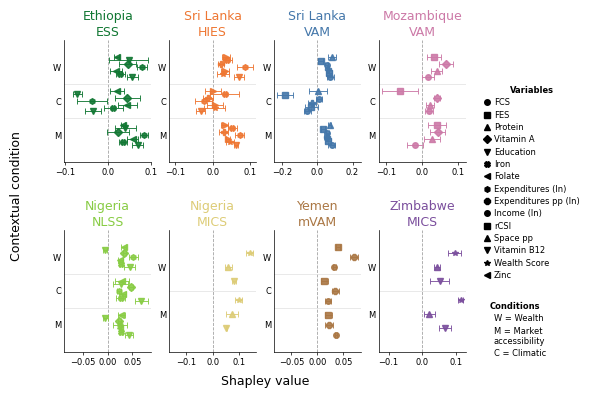

In [ ]:
# Cell 10 — Example plot
plot_shapley_subplot_grid(
    df=shapley_final,
    metric="imp_emd_over",
    out_path=str(BASE_DIR / "shapley_subplot_grid_imp_emd_over.png"),
)